In [79]:
import numpy as np
import matplotlib.pyplot as plt
import time
import seaborn as sns
from sklearn.datasets import make_blobs, load_breast_cancer, make_circles
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score
from lightgbm import LGBMClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC





### zad 1

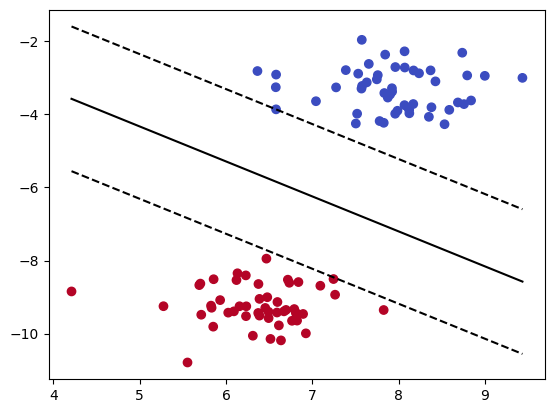

In [80]:
def train_svm(X, y, lr=0.001, lambda_param=0.01, epochs=1000):
    n_features = X.shape[1]
    w = np.zeros(n_features)
    b = 0

    for _ in range(epochs):
        for i, x_i in enumerate(X):
            condition = y[i] * (np.dot(x_i, w) + b) >= 1
            if condition:
                w -= lr * (2 * lambda_param * w)
            else:
                w -= lr * (2 * lambda_param * w - x_i * y[i])
                b -= lr * y[i]
    return w, b

X, y = make_blobs(n_samples=100, centers=2, random_state=6, cluster_std=0.60)
y = np.where(y == 0, -1, 1)

w, b = train_svm(X, y)

fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
plt.scatter(X[:, 0], X[:, 1], marker='o', c=y, cmap='coolwarm')

x0_min = np.amin(X[:, 0])
x0_max = np.amax(X[:, 0])
x1_decision_min = (-w[0] * x0_min - b) / w[1]
x1_decision_max = (-w[0] * x0_max - b) / w[1]
x1_margin_neg_min = (-w[0] * x0_min - b - 1) / w[1]
x1_margin_neg_max = (-w[0] * x0_max - b - 1) / w[1]
x1_margin_pos_min = (-w[0] * x0_min - b + 1) / w[1]
x1_margin_pos_max = (-w[0] * x0_max - b + 1) / w[1]
ax.plot([x0_min, x0_max], [x1_decision_min, x1_decision_max], 'k')
ax.plot([x0_min, x0_max], [x1_margin_neg_min, x1_margin_neg_max], 'k--')
ax.plot([x0_min, x0_max], [x1_margin_pos_min, x1_margin_pos_max], 'k--')

plt.show()

### zad 2

In [81]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

clf = SVC(kernel='linear')
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred, target_names=data.target_names))

0.9649122807017544
              precision    recall  f1-score   support

   malignant       0.97      0.94      0.95        63
      benign       0.96      0.98      0.97       108

    accuracy                           0.96       171
   macro avg       0.97      0.96      0.96       171
weighted avg       0.96      0.96      0.96       171



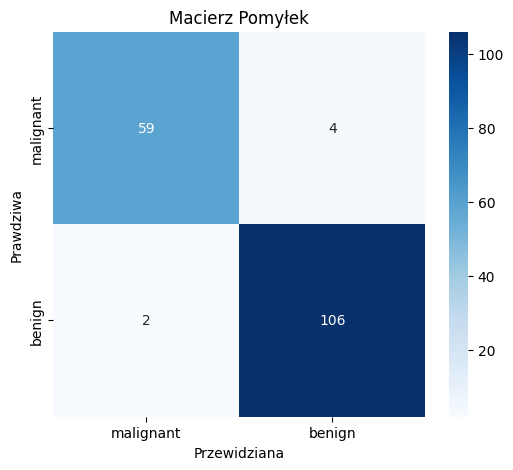

In [82]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=data.target_names, yticklabels=data.target_names)
plt.xlabel('Przewidziana')
plt.ylabel('Prawdziwa')
plt.title('Macierz Pomyłek')
plt.show()

### zad 3

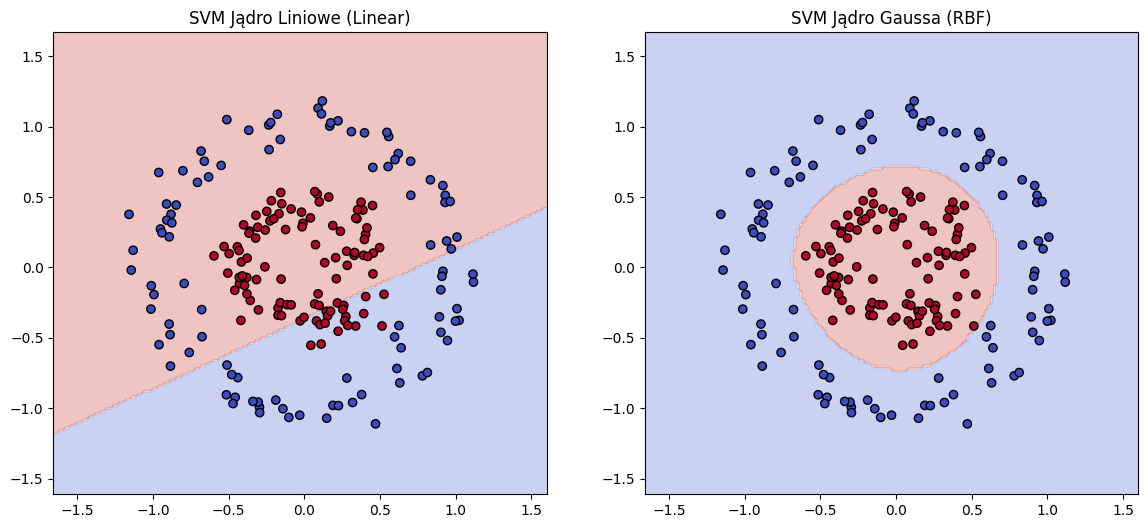

In [83]:
X, y = make_circles(n_samples=200, factor=0.4, noise=0.1, random_state=42)

clf_linear = SVC(kernel='linear')
clf_linear.fit(X, y)

clf_rbf = SVC(kernel='rbf')
clf_rbf.fit(X, y)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

def plot_decision_boundary(ax, clf, title):
    h = .02
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                         np.arange(y_min, y_max, h))
    
    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)
    
    ax.contourf(xx, yy, Z, cmap=plt.cm.coolwarm, alpha=0.3)
    ax.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.coolwarm, edgecolors='k')
    ax.set_title(title)

plot_decision_boundary(axes[0], clf_linear, "SVM Jądro Liniowe (Linear)")
plot_decision_boundary(axes[1], clf_rbf, "SVM Jądro Gaussa (RBF)")

plt.show()

### zad 4

In [84]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf'))
])

param_grid = {
    'svm__C': [0.1, 1, 10, 100], 
    'svm__gamma': [1, 0.1, 0.01, 0.001, 0.0001]
}

grid = GridSearchCV(pipe, param_grid, refit=True, cv=5)
grid.fit(X_train, y_train)
pred_grid = grid.predict(X_test)

print(f"Accuracy (Model Dostrojony + Skalowanie): {accuracy_score(y_test, pred_grid):.4f}")
print(f"\nNajlepsze parametry: {grid.best_params_}")
print(classification_report(y_test, pred_grid, target_names=data.target_names))

Accuracy (Model Dostrojony + Skalowanie): 0.9883

Najlepsze parametry: {'svm__C': 10, 'svm__gamma': 0.01}
              precision    recall  f1-score   support

   malignant       1.00      0.97      0.98        63
      benign       0.98      1.00      0.99       108

    accuracy                           0.99       171
   macro avg       0.99      0.98      0.99       171
weighted avg       0.99      0.99      0.99       171



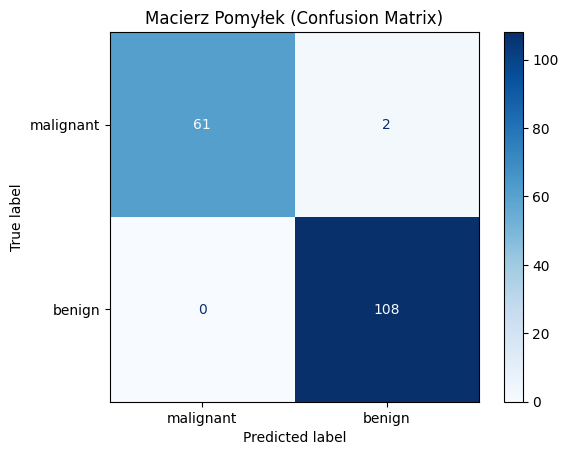

In [85]:
cm = confusion_matrix(y_test, pred_grid)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=data.target_names)

disp.plot(cmap=plt.cm.Blues)
plt.title("Macierz Pomyłek (Confusion Matrix)")
plt.show()

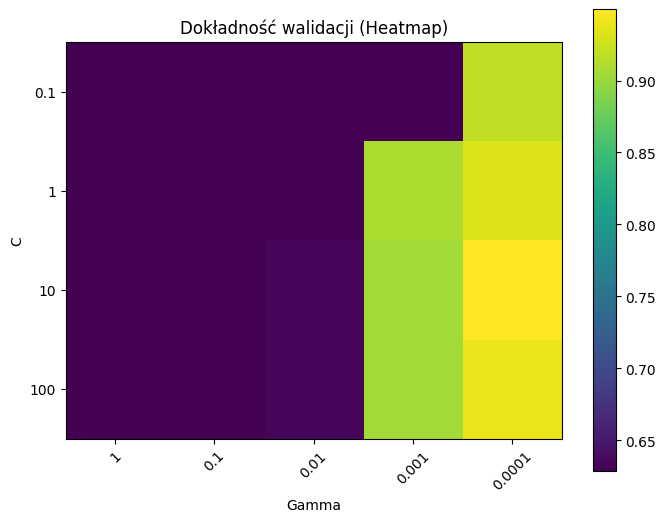

In [86]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

param_grid = {'C': [0.1, 1, 10, 100], 
              'gamma': [1, 0.1, 0.01, 0.001, 0.0001],
              'kernel': ['rbf']}

grid = GridSearchCV(SVC(), param_grid, refit=True, cv=5)
grid.fit(X_train, y_train)

scores = grid.cv_results_['mean_test_score'].reshape(len(param_grid['C']), len(param_grid['gamma']))

plt.figure(figsize=(8, 6))
plt.imshow(scores, interpolation='nearest', cmap='viridis')
plt.xlabel('Gamma')
plt.ylabel('C')
plt.colorbar()
plt.xticks(np.arange(len(param_grid['gamma'])), param_grid['gamma'], rotation=45)
plt.yticks(np.arange(len(param_grid['C'])), param_grid['C'])
plt.title('Dokładność walidacji (Heatmap)')
plt.show()

### zad 5

In [87]:
data = load_breast_cancer()
X = data.data
y = data.target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

start_xgb = time.time()
model_xgb = XGBClassifier(eval_metric='logloss')
model_xgb.fit(X_train, y_train)
end_xgb = time.time()
time_xgb = end_xgb - start_xgb
acc_xgb = accuracy_score(y_test, model_xgb.predict(X_test))

start_lgbm = time.time()
model_lgbm = LGBMClassifier(verbose=-1)
model_lgbm.fit(X_train, y_train)
end_lgbm = time.time()
time_lgbm = end_lgbm - start_lgbm
acc_lgbm = accuracy_score(y_test, model_lgbm.predict(X_test))

print(f"XGBoost  - Czas: {time_xgb:.5f} s, Dokładność: {acc_xgb:.4f}")
print(f"LightGBM - Czas: {time_lgbm:.5f} s, Dokładność: {acc_lgbm:.4f}")

if time_lgbm < time_xgb:
    print(f"\nLightGBM był szybszy o {time_xgb / time_lgbm:.2f} razy.")
else:
    print(f"\nXGBoost był szybszy o {time_lgbm / time_xgb:.2f} razy.")

XGBoost  - Czas: 0.07480 s, Dokładność: 0.9561
LightGBM - Czas: 0.05984 s, Dokładność: 0.9649

LightGBM był szybszy o 1.25 razy.


c:\Users\bartek\Desktop\Ai\.venv\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [88]:
def benchmark_models(X, y, n_loops=100):
    xgb_times = []
    lgbm_times = []

    
    for _ in range(n_loops):
        
        start = time.time()
        model_xgb = XGBClassifier(eval_metric='logloss')
        model_xgb.fit(X, y)
        xgb_times.append(time.time() - start)
        
        start = time.time()
        model_lgbm = LGBMClassifier(verbose=-1)
        model_lgbm.fit(X, y)
        lgbm_times.append(time.time() - start)
        
    avg_xgb = np.mean(xgb_times)
    avg_lgbm = np.mean(lgbm_times)
    
    print(f"Średni czas XGBoost: {avg_xgb:.4f} s")
    print(f"Średni czas LightGBM: {avg_lgbm:.4f} s")
    print(f"LightGBM jest średnio {avg_xgb / avg_lgbm:.2f}x szybszy.")

benchmark_models(X_train, y_train)

Średni czas XGBoost: 0.1093 s
Średni czas LightGBM: 0.1081 s
LightGBM jest średnio 1.01x szybszy.


### zad 6

In [89]:
data = load_breast_cancer()
X = data.data
y = data.target

model = XGBClassifier(eval_metric='logloss')

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(model, X, y, cv=skf)

print(f"Wyniki dla poszczególnych fałd (folds): {scores}")
print(f"Średnia dokładność: {np.mean(scores):.4f}")
print(f"Odchylenie standardowe: {np.std(scores):.4f}")

Wyniki dla poszczególnych fałd (folds): [0.95614035 0.93859649 0.96491228 0.94736842 0.95575221]
Średnia dokładność: 0.9526
Odchylenie standardowe: 0.0089
